<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/Diabetes_Prediction_Deep_Learning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Accuracy: 0.7662337662337663
Confusion Matrix:
 [[82 17]
 [19 36]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



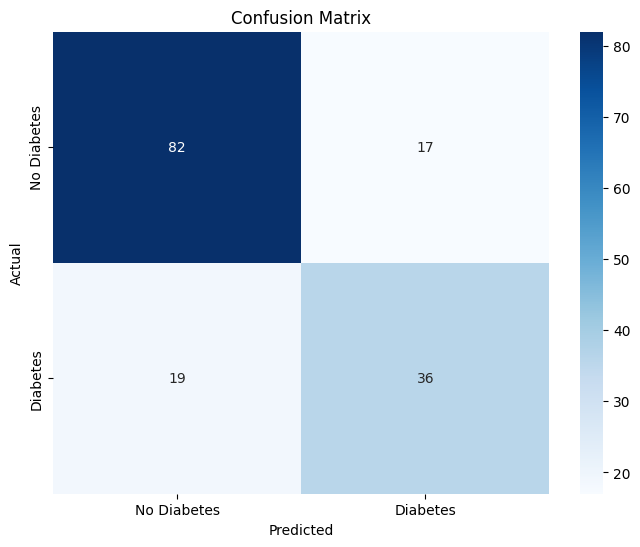

In [ ]:
class DiabetesModelPipeline:
  def __init__(self, file_path):
    self.file_path = file_path
    self.model = None
    self.history = None
    self.df = None
    self.label_encoder = LabelEncoder()
    self.preprocessor = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None

  def load_data(self):
    try:
      self.df = pd.read_csv(self.file_path)
      return self.df
    except Exception as e:
      print(f"Error loading data: {e}")
      return None

  def preprocess(self):
    df = self.df
    target_col = "Outcome"

    if df.isnull().sum().sum() > 0:
      df = df.fillna(method='ffill')

    X = df.drop(columns=[target_col])
    y = df[target_col]

    self.y_encoded = self.label_encoder.fit_transform(y)

    categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
    numerical_cols = [c for c in X.columns if X[c].dtype != 'object']

    self.preprocessor = ColumnTransformer(
      transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
      ])

    X_processed = self.preprocessor.fit_transform(X)

    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        X_processed, self.y_encoded, test_size=0.2, random_state=42
    )

  def build_model(self, input_dim):
    model = keras.Sequential([
      layers.Dense(32, activation='relu', input_shape=(input_dim,)),
      layers.Dropout(0.2),
      layers.Dense(16, activation='relu'),
      layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

  def train_model(self):
    input_dim = self.X_train.shape[1]
    self.model = self.build_model(input_dim)
    self.history = self.model.fit(
        self.X_train, self.y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

  def evaluate_model(self):
    y_pred_prob = self.model.predict(self.X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)
    accuracy = accuracy_score(self.y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    cm = confusion_matrix(self.y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    print(classification_report(self.y_test, y_pred))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Instantiate and run the pipeline
pipeline = DiabetesModelPipeline('/content/sample_data/diabetes.csv')
pipeline.load_data()
pipeline.preprocess()
pipeline.train_model()
pipeline.evaluate_model()